In [1]:
import pandas as pd

In [2]:
df=pd.read_excel('data/Raisin_Dataset.xlsx')
df.head()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter,Class
0,87524,442.246011,253.291155,0.819738,90546,0.758651,1184.040,Kecimen
1,75166,406.690687,243.032436,0.801805,78789,0.684130,1121.786,Kecimen
2,90856,442.267048,266.328318,0.798354,93717,0.637613,1208.575,Kecimen
3,45928,286.540559,208.760042,0.684989,47336,0.699599,844.162,Kecimen
4,79408,352.190770,290.827533,0.564011,81463,0.792772,1073.251,Kecimen


In [3]:
from sklearn.model_selection import train_test_split
x=df.drop('Class',axis=1)
y=df['Class']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

<h1>SVM model training</h1>

In [4]:
from sklearn.svm import SVC
model=SVC(kernel='rbf')
model.fit(x_train,y_train)
y_pred=model.predict(x_test)

In [ ]:
model.n_iter_ #kernel='rbf', iteration is 225

array([225], dtype=int32)

In [18]:
model1=SVC(kernel='linear')
model1.fit(x_train,y_train)
y_pred1=model1.predict(x_test)

In [19]:
model1.n_iter_ #kernel='linear', iteration is 292224717

array([292224717], dtype=int32)

<h1>Performance of models with different parameter</h1>

In [5]:
from sklearn.metrics import classification_report, confusion_matrix

In [7]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

       Besni       0.88      0.79      0.83        86
     Kecimen       0.83      0.90      0.86        94

    accuracy                           0.85       180
   macro avg       0.85      0.85      0.85       180
weighted avg       0.85      0.85      0.85       180



In [9]:
cm=confusion_matrix(y_test,y_pred)
print(cm)

[[68 18]
 [ 9 85]]


<Axes: >

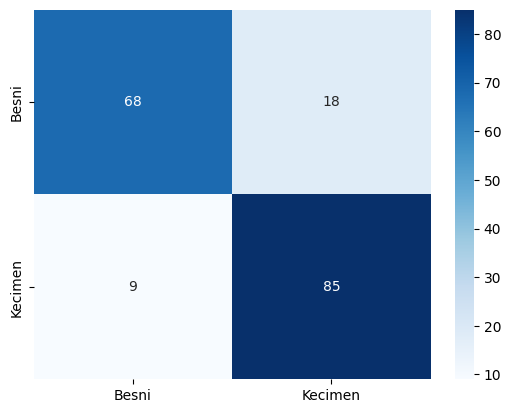

In [10]:
import seaborn as sns
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=model.classes_,yticklabels=model.classes_)

In [20]:
print(classification_report(y_test,y_pred1))

              precision    recall  f1-score   support

       Besni       0.82      0.90      0.86        86
     Kecimen       0.90      0.82      0.86        94

    accuracy                           0.86       180
   macro avg       0.86      0.86      0.86       180
weighted avg       0.86      0.86      0.86       180



In [22]:
cm1=confusion_matrix(y_test,y_pred1)
print(cm1)

[[77  9]
 [17 77]]


<Axes: >

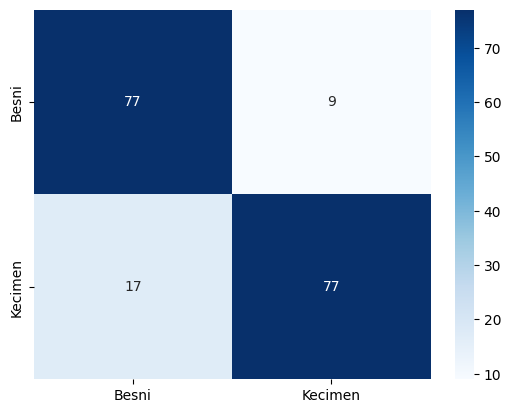

In [23]:
sns.heatmap(cm1,annot=True,fmt='d',cmap='Blues',xticklabels=model1.classes_,yticklabels=model1.classes_)